In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("play_golf.csv")
df.head()

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
0,Rainy,Hot,High,False,No
1,Rainy,Hot,High,True,No
2,Overcast,Hot,High,False,Yes
3,Sunny,Mild,High,False,Yes
4,Sunny,Cool,Normal,False,Yes


C:\Users\91742\AppData\Local\Temp\ipykernel_24316\4133308870.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='TEMPERATURE',y='OUTLOOK',palette='husl',data=df)


<Axes: xlabel='TEMPERATURE', ylabel='OUTLOOK'>

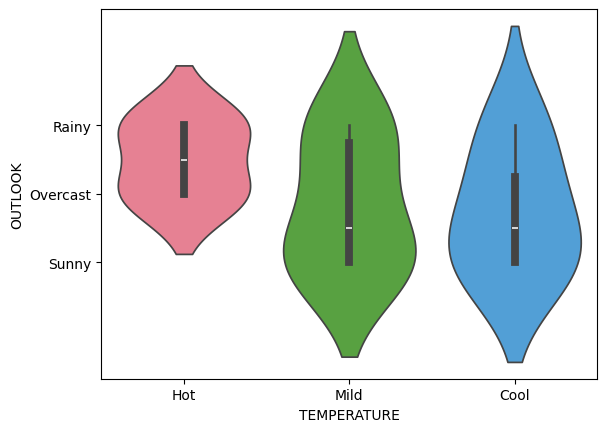

In [4]:
sns.violinplot(x='TEMPERATURE',y='OUTLOOK',palette='husl',data=df)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OUTLOOK      14 non-null     object
 1   TEMPERATURE  14 non-null     object
 2   HUMIDITY     14 non-null     object
 3   WINDY        14 non-null     bool  
 4   PLAY GOLF    14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes


In [6]:
df.describe()

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY,PLAY GOLF
count,14,14,14,14,14
unique,3,3,2,2,2
top,Rainy,Mild,High,False,Yes
freq,5,6,7,8,9


In [7]:
df.isnull().sum()

OUTLOOK        0
TEMPERATURE    0
HUMIDITY       0
WINDY          0
PLAY GOLF      0
dtype: int64

In [8]:
X = df.drop('PLAY GOLF',axis=1)
Y =df['PLAY GOLF']

In [9]:
from sklearn.model_selection import train_test_split
X_tarin,X_test,Y_train,Y_test = train_test_split(X,Y, random_state= 42,test_size=0.25)

In [10]:
X_tarin.head()

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY
5,Sunny,Cool,Normal,True
8,Rainy,Cool,Normal,False
2,Overcast,Hot,High,False
1,Rainy,Hot,High,True
13,Sunny,Mild,High,True


In [11]:
X_test.head()

,OUTLOOK,TEMPERATURE,HUMIDITY,WINDY
9,Sunny,Mild,Normal,False
11,Overcast,Mild,High,True
0,Rainy,Hot,High,False
12,Overcast,Hot,Normal,False


In [12]:
Y_train.head()

5      No
8     Yes
2     Yes
1      No
13     No
Name: PLAY GOLF, dtype: object

In [13]:
Y_test.head()

9     Yes
11    Yes
0      No
12    Yes
Name: PLAY GOLF, dtype: object

In [14]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

## Label Encoder

In [15]:
label_encoder = LabelEncoder()
df['OUTLOOK_label'] = label_encoder.fit_transform(df['OUTLOOK'])
df['PLAY GOLF_label'] = label_encoder.fit_transform(df['PLAY GOLF'])
print(df)

     OUTLOOK TEMPERATURE HUMIDITY  WINDY PLAY GOLF  OUTLOOK_label  \
0      Rainy         Hot     High  False        No              1   
1      Rainy         Hot     High   True        No              1   
2   Overcast         Hot     High  False       Yes              0   
3      Sunny        Mild     High  False       Yes              2   
4      Sunny        Cool   Normal  False       Yes              2   
5      Sunny        Cool   Normal   True        No              2   
6   Overcast        Cool   Normal   True       Yes              0   
7      Rainy        Mild     High  False        No              1   
8      Rainy        Cool   Normal  False       Yes              1   
9      Sunny        Mild   Normal  False       Yes              2   
10     Rainy        Mild   Normal   True       Yes              1   
11  Overcast        Mild     High   True       Yes              0   
12  Overcast         Hot   Normal  False       Yes              0   
13     Sunny        Mild     High 

In [16]:
onehot_encoder = OneHotEncoder()
OUTLOOK_encoder = onehot_encoder.fit_transform(df[['OUTLOOK']]).toarray()
df = df.join(pd.DataFrame(OUTLOOK_encoder,columns=onehot_encoder.get_feature_names_out(['OUTLOOK'])))
print(df)

     OUTLOOK TEMPERATURE HUMIDITY  WINDY PLAY GOLF  OUTLOOK_label  \
0      Rainy         Hot     High  False        No              1   
1      Rainy         Hot     High   True        No              1   
2   Overcast         Hot     High  False       Yes              0   
3      Sunny        Mild     High  False       Yes              2   
4      Sunny        Cool   Normal  False       Yes              2   
5      Sunny        Cool   Normal   True        No              2   
6   Overcast        Cool   Normal   True       Yes              0   
7      Rainy        Mild     High  False        No              1   
8      Rainy        Cool   Normal  False       Yes              1   
9      Sunny        Mild   Normal  False       Yes              2   
10     Rainy        Mild   Normal   True       Yes              1   
11  Overcast        Mild     High   True       Yes              0   
12  Overcast         Hot   Normal  False       Yes              0   
13     Sunny        Mild     High 

In [17]:
from category_encoders import BinaryEncoder,TargetEncoder,HashingEncoder

## Binary Encoder
binary_encoder = BinaryEncoder()
df_binary = binary_encoder.fit_transform

In [18]:
binary_encoder = BinaryEncoder()
df_binary = binary_encoder.fit_transform(df[['OUTLOOK']])
print(df_binary)

    OUTLOOK_0  OUTLOOK_1
0           0          1
1           0          1
2           1          0
3           1          1
4           1          1
5           1          1
6           1          0
7           0          1
8           0          1
9           1          1
10          0          1
11          1          0
12          1          0
13          1          1


## Target Encoder

In [19]:
target_encoder = TargetEncoder()
df['OUTLOOK_target']= target_encoder.fit_transform(df['OUTLOOK'],df['TEMPERATURE'])
print(df)                                                 

AttributeError: 'numpy.ndarray' object has no attribute 'groupby'